In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from bayes.optimizer import ExperimentOptimizer, plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
df = pd.read_csv("../data/direct_arylation.csv")
name = "test"
description = "test demo"
variables = [
    {
        "name": "Ligand",
        "param_type": "Categorical",
        "chooses": df["Ligand_Name"].unique().tolist(),
    },
    {
        "name": "Base",
        "param_type": "Categorical",
        "chooses": df["Base_Name"].unique().tolist(),
    },
    {
        "name": "Solvent",
        "param_type": "Categorical",
        "chooses": df["Solvent_Name"].unique().tolist(),
    },
    {
        "name": "T",
        "param_type": "Discrete",
        "chooses": df["Temp_C"].unique().tolist(),
    },
    {
        "name": "C",
        "param_type": "Discrete",
        "chooses": df["Concentration"].unique().tolist(),
    },
]
objectives = [
    {
        "name": "Yield",
        "target_type": "maximize",
    }
]

bo_config = {
    "n_iterations": 10,
    "n_initial_points": 6,
    "surrogate_model": "GP",
}


In [46]:
def carry_experiments(conditions):
    results = []
    for condition in conditions:
        query = (
            f"Base_Name == '{condition['Base']}' and "
            f"Ligand_Name == '{condition['Ligand']}' and "
            f"Solvent_Name == '{condition['Solvent']}' and "
            f"Concentration == {condition['C']} and "
            f"Temp_C == {condition['T']}"
        )
        result = df.query(query)
        if result.empty:
            results.append({"Yield": -1})
        else:
            results.append({"Yield": result["yield"].to_list()[0]})

    return results


def step(expt_id, iteration, batch_size):
    conditions = ExperimentOptimizer.ask(expt_id, batch_size)  # type: ignore
    results = carry_experiments(conditions)
    ExperimentOptimizer.tell(expt_id, iteration, conditions, results)  # type: ignore

In [47]:
batch_size = 3
epoch_num = 10

expt_id = ExperimentOptimizer.setup(
    name=name,
    description=description,
    variables=variables,
    objectives=objectives,
    bo_config=bo_config,
)

for i in range(epoch_num):
    step(expt_id, i + 1, batch_size)


[]

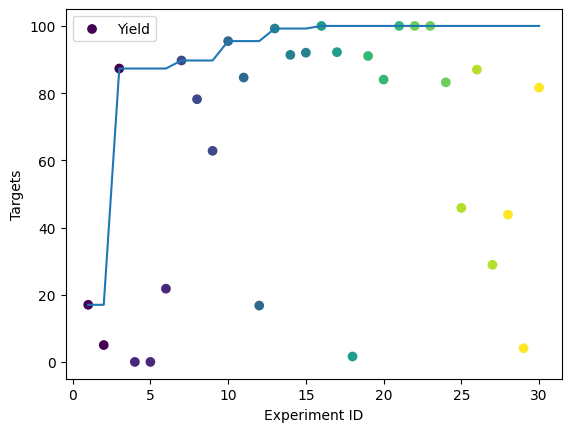

In [48]:
plot(expt_id)